current issue : 
model is learning only from 9 features 
This is enough to get a working demo, but it's not enough for a high-quality anomaly detector.

to fix : 
extract these additional features from Raw_Log


Raw Log
    ↓
Regex Parser
    ↓
20 Structured Features
    ↓
Feature Engineering
    ↓
Isolation Forest
    ↓
Anomaly
    ↓
LLM

                Raw Log File
                      │
                      ▼
             Log Parser (Regex)
                      │
                      ▼
          Structured DataFrame (23+ Features)
                      │
                      ▼
            Feature Engineering
                      │
                      ▼
           Isolation Forest Model
                      │
          ┌───────────┴───────────┐
          │                       │
      Normal Log            Anomalous Log
          │                       │
       Ignore             Root Cause Extraction
                                  │
                                  ▼
                          Build LLM Context
                                  │
                                  ▼
                             Gemini / GPT
                                  │
                                  ▼
                    Cause + Fix + Recommendation

other models than Isolation forest : 
LSTM AutoEncoder and Transformer(logBERT)

| Company   | Technique                                                    |
| --------- | ------------------------------------------------------------ |
| Dynatrace | Davis AI (causal AI + dependency graphs + anomaly detection) |
| Splunk    | Deep Learning + Statistical Models                           |
| Datadog   | Time Series + ML + Forecasting                               |
| Microsoft | LogBERT                                                      |
| Google    | DeepLog / LSTM variants                                      |
| IBM       | AutoEncoder + NLP                                            |
| Amazon    | Random Cut Forest + Deep Learning                            |


Detecting anomalous events in online computer systems is crucial to protect the systems from malicious attacks or malfunctions. System logs, which record detailed information of computational events, are widely used for system status analysis. In this paper, we propose LogBERT, a self-supervised framework for log anomaly detection based on Bidirectional Encoder Representations from Transformers (BERT). LogBERT learns the patterns of normal log sequences by two novel self-supervised training tasks and is able to detect anomalies where the underlying patterns deviate from normal log sequences. The experimental results on three log datasets show that LogBERT outperforms state-of-the-art approaches for anomaly detection.

source : https://arxiv.org/abs/2103.04475

https://github.com/HelenGuohx/logbert

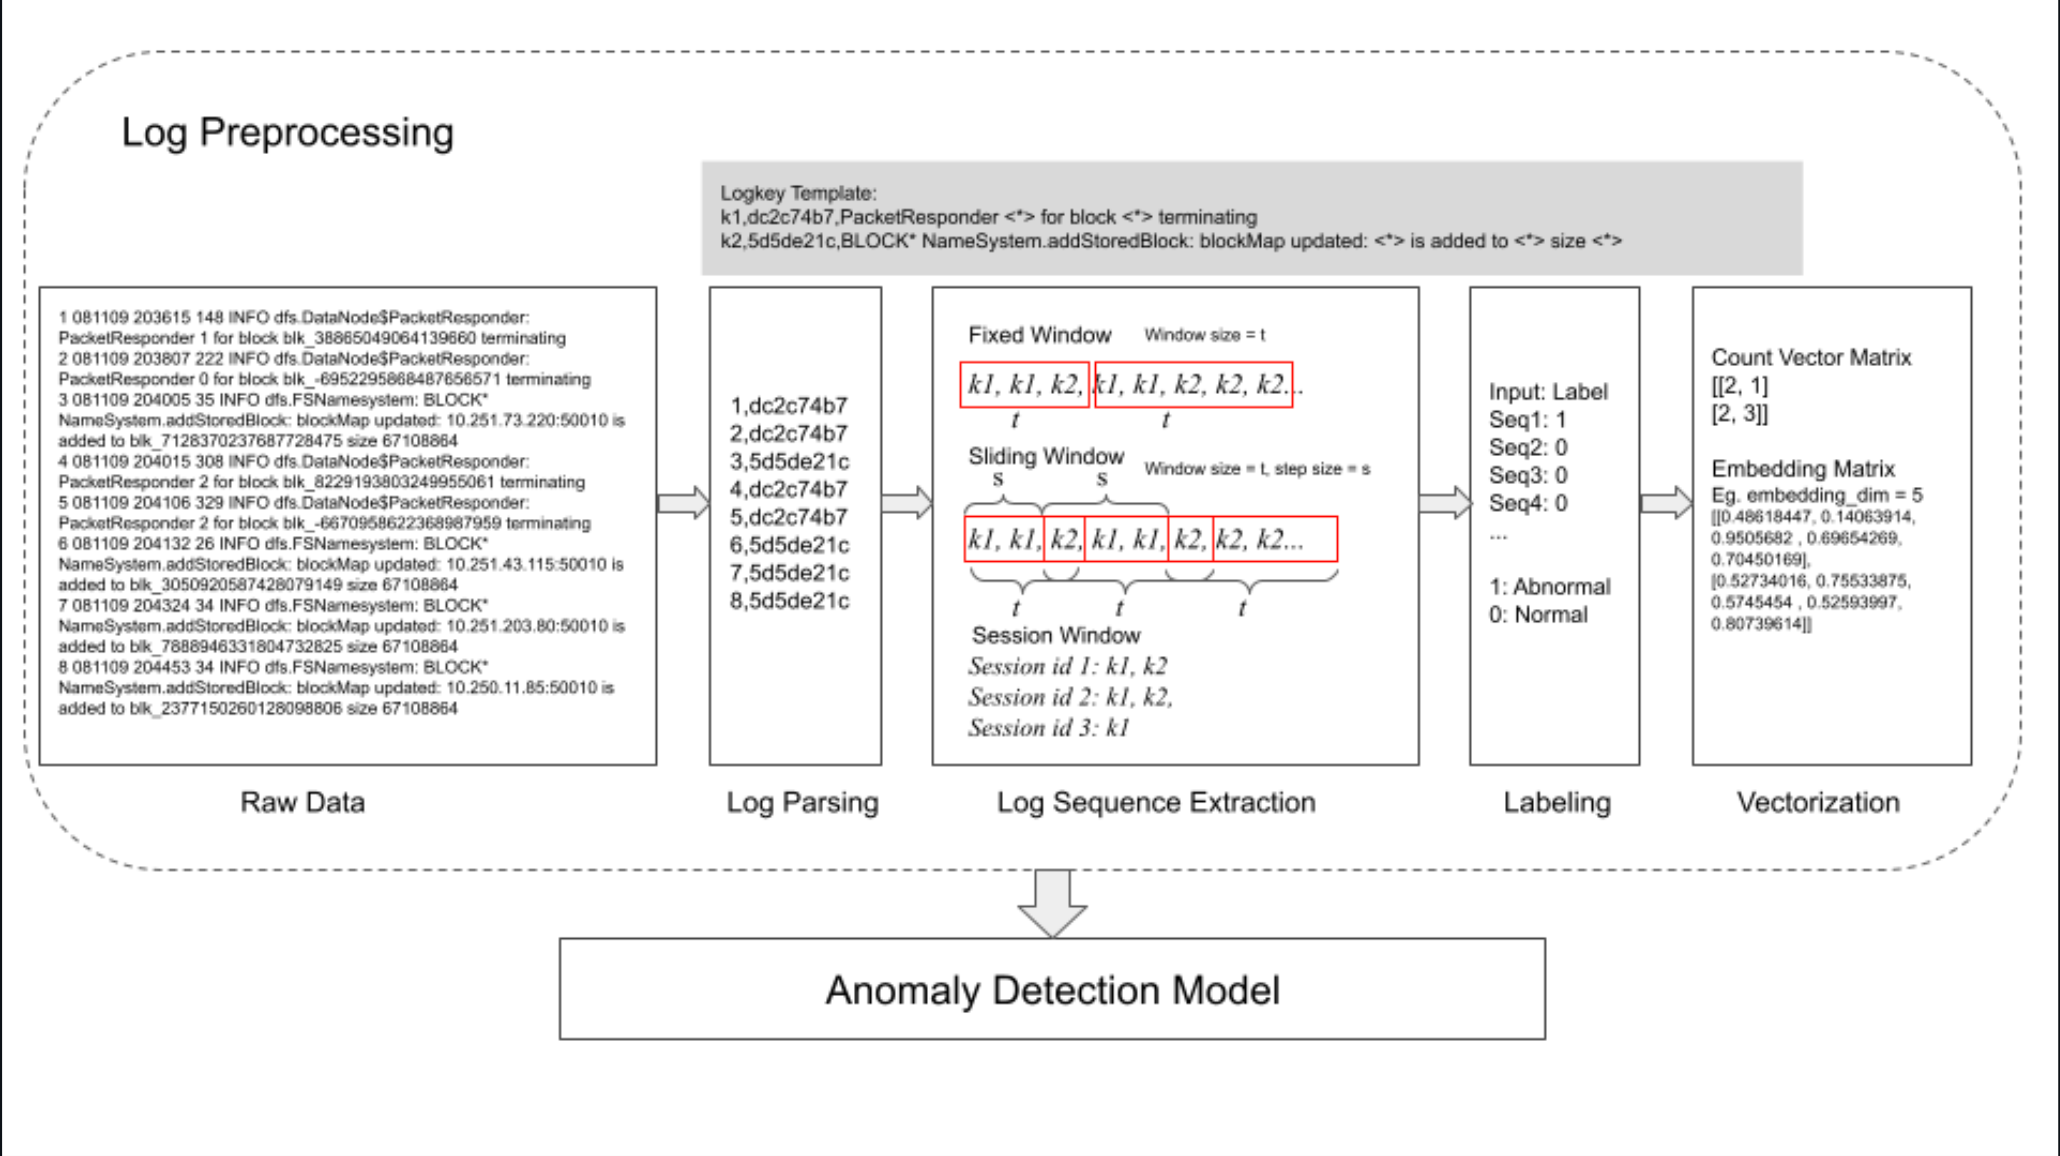

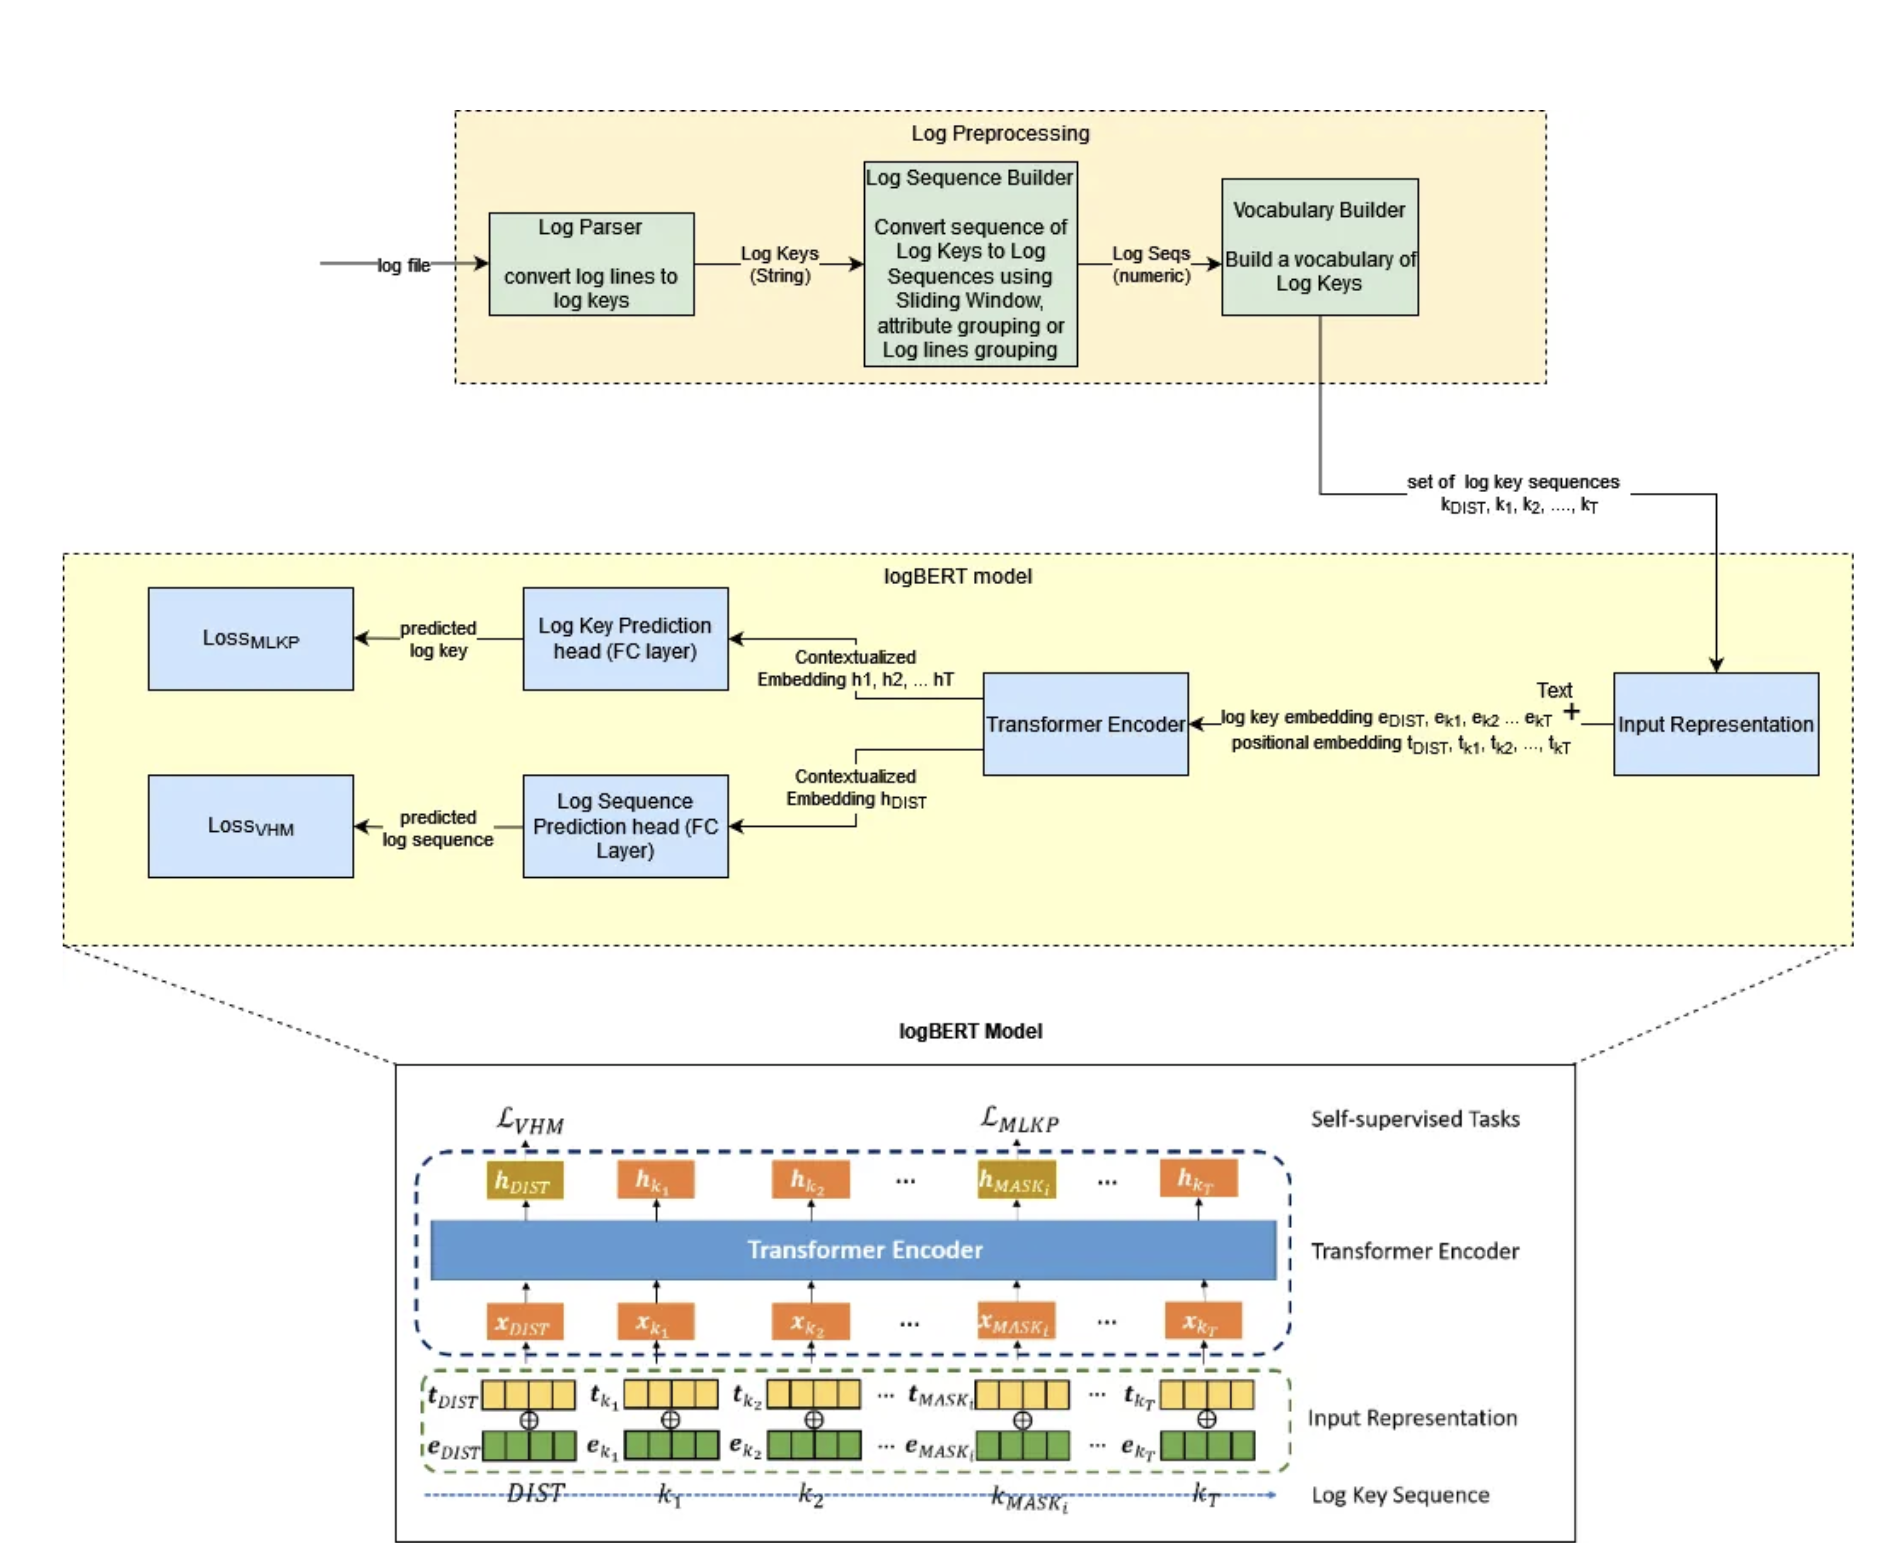

medium blog 
https://medium.com/infinstor/logbert-log-file-anomaly-detection-using-bert-an-explainer-db20bfd2f91f

| Company             | Product / Platform        | Technique Used                                                                                     | AI / ML Model                                                                                            |
| ------------------- | ------------------------- | -------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------- |
| Microsoft           | Azure Monitor / Research  | Deep learning for log sequences                                                                    | **LogBERT**, Transformer-based log modeling (published by Microsoft researchers) ([arXiv][1])            |
| Google              | Google production systems | Sequential log prediction                                                                          | **DeepLog (LSTM)**, sequence modeling (research from the Google ecosystem is widely adopted in practice) |
| Amazon Web Services | CloudWatch                | Random Cut Forest + statistical anomaly detection for metrics, combined with rule engines for logs | **Random Cut Forest (RCF)** for anomaly detection, not primarily for raw log semantics                   |
| Dynatrace           | Davis AI                  | Causal AI + dependency graphs + anomaly detection                                                  | Proprietary AI (not a published neural model) combining topology, causality, and ML                      |
| Datadog             | Watchdog AI               | Statistical learning + ML + time-series models                                                     | Proprietary ML ensemble                                                                                  |
| Splunk              | Splunk AI / ITSI          | Machine learning toolkit + NLP + forecasting                                                       | Proprietary ensemble models with deep learning support                                                   |
| IBM                 | Watson AIOps              | NLP + anomaly detection + root cause analysis                                                      | Hybrid deep learning + knowledge graph                                                                   |
| New Relic           | Applied Intelligence      | Correlation + anomaly detection                                                                    | Proprietary ML ensemble                                                                                  |
| Elastic             | Elastic ML                | Probabilistic time-series modeling                                                                 | Bayesian/statistical anomaly detection                                                                   |

[1]: https://arxiv.org/abs/2103.04475?utm_source=chatgpt.com "LogBERT: Log Anomaly Detection via BERT"


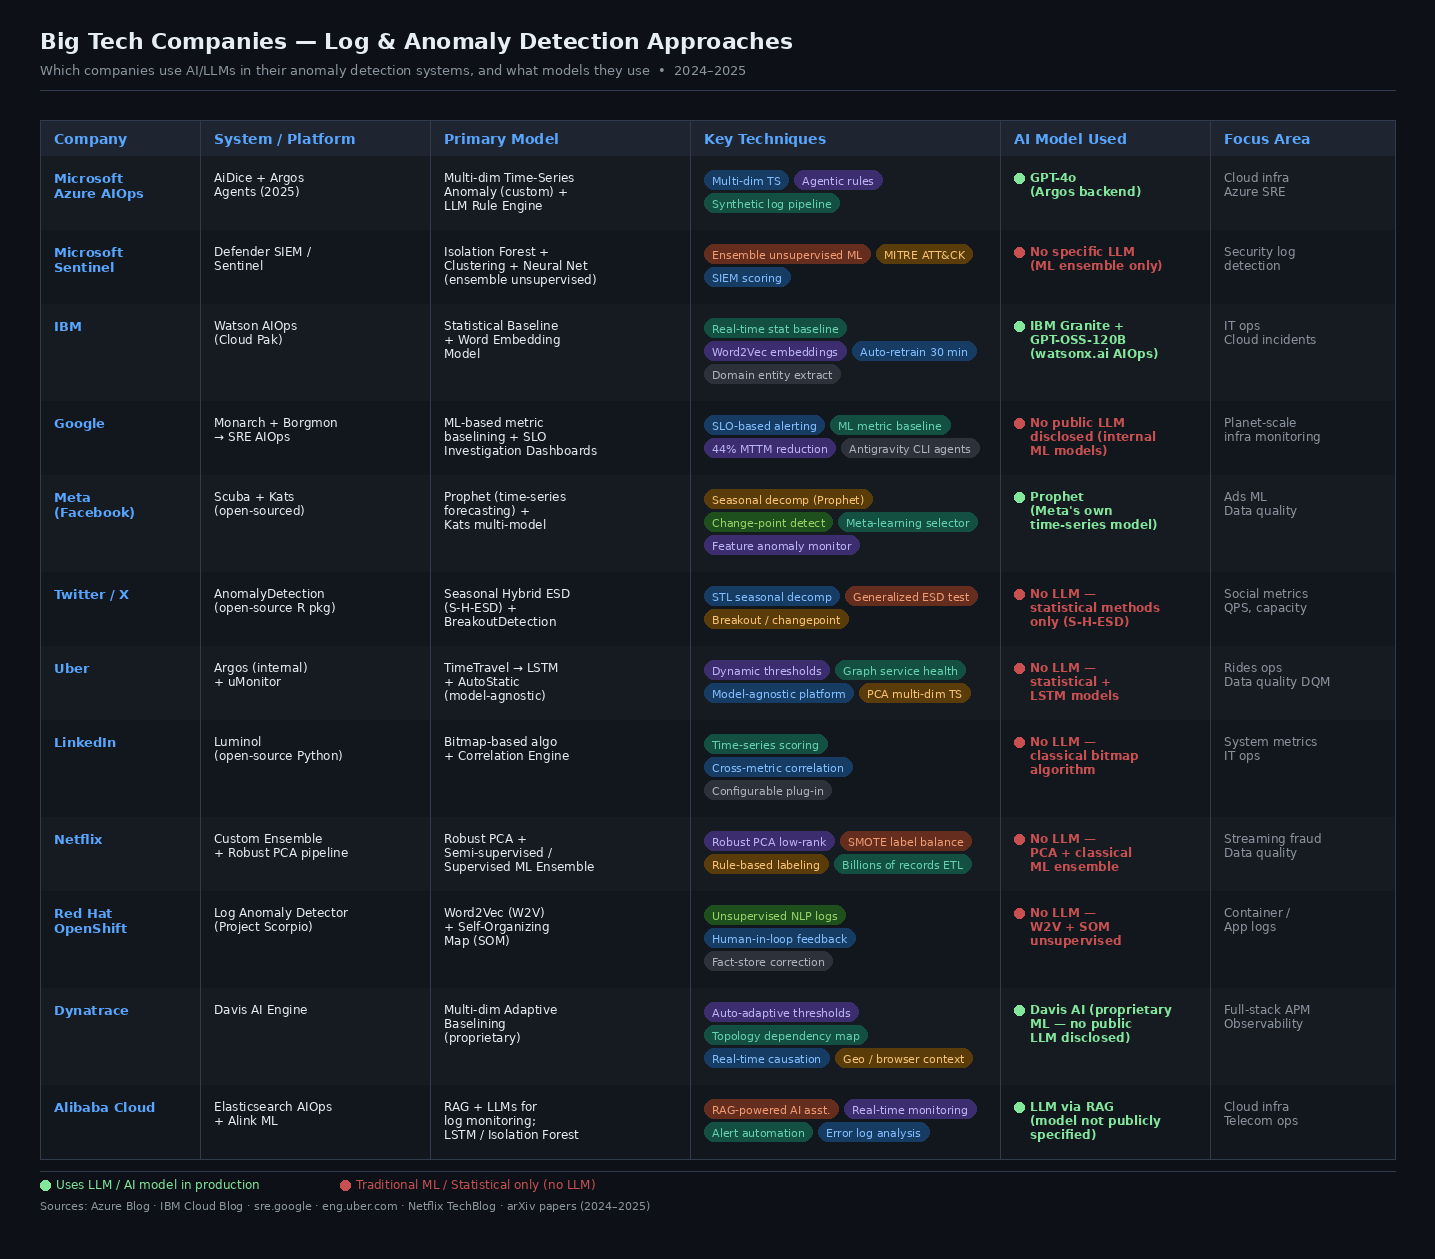

Raw Logs
      │
      ▼
Regex / Drain3 Parser
      │
      ▼
Structured Data
      │
      ▼
LogBERT / BERT
      │
      ▼
768-Dimensional Embeddings
      │
      ▼
Merge Structured Features
      │
      ▼
Deep AutoEncoder
      │
      ▼
Reconstruction Error
      │
      ▼
Anomaly Score
      │
      ▼
Context Builder
      │
      ▼
Gemini / GPT
      │
      ▼
Root Cause + Recommendation

In [ ]:
In the next iteration, we'll make parse_log() extract 20–30 structured fields from each log:

Component
Line Number
Timestamp
Severity
AccountID
Username
TPS
Queue Count
Router Status
Retry Count
Service ID
Message ID
Authentication Status
Error Flags
Warning Flags
Dynamic key-value pairs
Message length
Word count

In [ ]:
✅ Notebook 1 (Current)
 Read log file - done 
 Create parser function - done 
 Convert to DataFrame - done 
 Extract 20–30 structured fields (next step)
 Feature engineering
 Save processed_logs.csv

In [ ]:
🔜 Notebook 2
Load processed_logs.csv
Generate LogBERT embeddings for Raw_Log
Save embeddings to data/embeddings/
🔜 Notebook 3
Merge embeddings + structured features
Normalize features
Train the Deep AutoEncoder
Compute reconstruction error
Generate anomaly scores
🔜 Notebook 4
Build context around detected anomalies (related logs, nearby events, key fields)
🔜 Notebook 5
Send the anomaly context to Gemini/GPT
Get root cause analysis and remediation suggestions

                User copies log
                       │
                       ▼
        data/incoming_logs/server.log
                       │
                       ▼
            👀 Watchdog detects file
                       │
                       ▼
             preprocess(server.log)
                       │
                       ▼
             parser.py extracts features
                       │
                       ▼
             predictor.py loads model
                       │
                       ▼
             model.predict(features)
                       │
                       ▼
       data/predictions/server_prediction.csv
                       │
                       ▼
      Move original log → processed/archive

New .log File
      │
      ▼
Watchdog detects new file
      │
      ▼
Log Parser
      │
      ▼
Feature Extraction
      │
      ▼
Preprocessing
      │
      ▼
Anomaly Detection Model
      │
      ▼
Prediction Generation
      │
      ▼
Results Saved + Dashboard Update + Alerts



> This project can be further enhanced by incorporating richer contextual information into the Root Cause Analysis pipeline. Instead of relying only on the current log, anomaly score, severity, and nearby logs, additional features such as timestamp, queue count, transactions per second (TPS), packet number, source and destination addresses, username, account ID, routing status, queue insertion status, and response flags can be included to provide deeper operational insights. The anomaly detection model can also be improved by experimenting with advanced architectures such as Variational AutoEncoders (VAE), Transformer-based AutoEncoders, or Isolation Forest for comparison. Future improvements may include real-time log monitoring using Watchdog, automatic incident creation, interactive dashboards for anomaly visualization, alerting integrations (Slack, Teams, Email), historical trend analysis, retrieval-augmented generation (RAG) for domain-specific RCA, and fine-tuning open-source LLMs to generate more accurate, organization-specific root cause analyses and remediation recommendations. These enhancements would make the system more scalable, explainable, and production-ready for enterprise log monitoring. 
